In [223]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pickle

<h3>Загружаем датасет</h3>

In [224]:
# dataset https://www.kaggle.com/datasets/laveshjadon/ai-impact-on-students

df = pd.read_csv('../data/ai_student_impact.csv')

In [225]:
df.head(20)

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium
5,100006,STEM,Junior,3.449,6.50,Debugging/Troubleshooting,Beginner,1,False,14.19,4,Allowed_With_Citation,5,3.666,65.92,High
6,100007,STEM,Freshman,3.622,31.41,Summarizing_Reading,Advanced,5,True,13.11,8,Allowed_With_Citation,7,4.000,67.97,Medium
7,100008,Arts,Junior,2.746,5.33,Copywriting/Drafting,Intermediate,3,False,18.45,2,Actively_Encouraged,1,2.965,85.09,Medium
8,100009,Business,Sophomore,3.420,2.00,Debugging/Troubleshooting,Beginner,2,True,2.87,1,Strict_Ban,5,3.396,55.71,Medium
9,100010,Business,Sophomore,3.046,19.99,Debugging/Troubleshooting,Intermediate,2,True,12.49,3,Strict_Ban,8,2.978,87.18,High


In [226]:
df.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  object 
 2   Year_of_Study               50000 non-null  object 
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            50000 non-null  object 
 6   Prompt_Engineering_Skill    50000 non-null  object 
 7   Tool_Diversity              50000 non-null  int64  
 8   Paid_Subscription           50000 non-null  bool   
 9   Traditional_Study_Hours     50000 non-null  float64
 10  Perceived_AI_Dependency     50000 non-null  int64  
 11  Institutional_Policy        50000 non-null  object 
 12  Anxiety_Level_During_Exams  50000 non-null  int64  
 13  Post_Semester_GPA           500

<h3>Очистка данных</h3>

In [227]:
# Обозначим категориальные столбцы

categorical_cols = [
    'Major_Category', 
    'Year_of_Study', 
    'Primary_Use_Case',
    'Prompt_Engineering_Skill', 
    'Institutional_Policy',
    'Burnout_Risk_Level'
]

df[categorical_cols] = df[categorical_cols].astype('category')

df['Year_of_Study'] = df['Year_of_Study'].cat.reorder_categories(
    ['Freshman', 'Sophomore', 'Junior', 'Senior', 'Graduate'], ordered=True)
df['Prompt_Engineering_Skill'] = df['Prompt_Engineering_Skill'].cat.reorder_categories(
    ['Beginner', 'Intermediate', 'Advanced'], ordered=True)
df['Burnout_Risk_Level'] = df['Burnout_Risk_Level'].cat.reorder_categories(
    ['Low', 'Medium', 'High'], ordered=True)

In [228]:
print(f"Память: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Память: 3.77 MB


In [229]:
# Даункаст

df['Student_ID'] = df['Student_ID'].astype('int32')
df['Tool_Diversity'] = df['Tool_Diversity'].astype('int8')
df['Perceived_AI_Dependency'] = df['Perceived_AI_Dependency'].astype('int8')
df['Anxiety_Level_During_Exams'] = df['Anxiety_Level_During_Exams'].astype('int8')

float_cols = [
    'Pre_Semester_GPA',
    'Post_Semester_GPA',
    'Weekly_GenAI_Hours',
    'Traditional_Study_Hours',
    'Skill_Retention_Score'
]
df[float_cols] = df[float_cols].astype('float32')


In [230]:
print(f"Память: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Память: 1.62 MB


In [231]:
df = df.drop(columns = ['Student_ID'])
print(f"Память: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Память: 1.43 MB


In [232]:
# Уберем некоторые краевые значения

df = df[df['Skill_Retention_Score'].between(20, 95)]
df = df[df['Weekly_GenAI_Hours'].between(0, 35)]
print(f"Память: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Память: 1.63 MB


<h3>EDA</h3>

In [233]:
df.describe()

,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score
count,44889.000000,44889.000000,44889.000000,44889.000000,44889.000000,44889.000000,44889.000000,44889.000000
mean,3.138932,7.923194,2.751454,11.148220,3.428591,4.241217,3.337184,73.847137
std,0.480164,7.374005,1.182696,5.133325,1.731944,2.130501,0.496021,11.661995
min,1.183000,0.000000,1.000000,1.000000,1.000000,1.000000,1.190000,21.250000
25%,2.825000,2.310000,2.000000,7.500000,2.000000,3.000000,3.012000,66.059998
50%,3.203000,5.610000,3.000000,11.120000,3.000000,4.000000,3.404000,74.690002
75%,3.515000,11.320000,3.000000,14.630000,5.000000,6.000000,3.736000,82.680000
max,3.997000,34.990002,5.000000,35.860001,10.000000,10.000000,4.000000,95.000000


In [234]:
cat_features = df.select_dtypes(include=['category'])
print(cat_features.columns.to_list())

['Major_Category', 'Year_of_Study', 'Primary_Use_Case', 'Prompt_Engineering_Skill', 'Institutional_Policy', 'Burnout_Risk_Level']


In [235]:
num_features = df.select_dtypes(include=[np.number])
print(num_features.columns.to_list())

['Pre_Semester_GPA', 'Weekly_GenAI_Hours', 'Tool_Diversity', 'Traditional_Study_Hours', 'Perceived_AI_Dependency', 'Anxiety_Level_During_Exams', 'Post_Semester_GPA', 'Skill_Retention_Score']


In [236]:
for cat in cat_features:
    print(f'{cat} - numer of unique = {df[cat].nunique()}')

Major_Category - numer of unique = 5
Year_of_Study - numer of unique = 5
Primary_Use_Case - numer of unique = 5
Prompt_Engineering_Skill - numer of unique = 3
Institutional_Policy - numer of unique = 3
Burnout_Risk_Level - numer of unique = 3


In [237]:
for col in cat_features:
    print(f'Unique categories in {df[col].value_counts()}\n\n')

Unique categories in Major_Category
STEM          12832
Business      11450
Humanities     9289
Medical        5883
Arts           5435
Name: count, dtype: int64


Unique categories in Year_of_Study
Junior       10092
Freshman     10024
Senior        9274
Sophomore     8970
Graduate      6529
Name: count, dtype: int64


Unique categories in Primary_Use_Case
Copywriting/Drafting         11123
Debugging/Troubleshooting    10214
Ideation                      9808
Summarizing_Reading           7942
Direct_Answer_Generation      5802
Name: count, dtype: int64


Unique categories in Prompt_Engineering_Skill
Beginner        17642
Intermediate    16246
Advanced        11001
Name: count, dtype: int64


Unique categories in Institutional_Policy
Allowed_With_Citation    22601
Actively_Encouraged      13431
Strict_Ban                8857
Name: count, dtype: int64


Unique categories in Burnout_Risk_Level
Medium    19249
Low       14940
High      10700
Name: count, dtype: int64




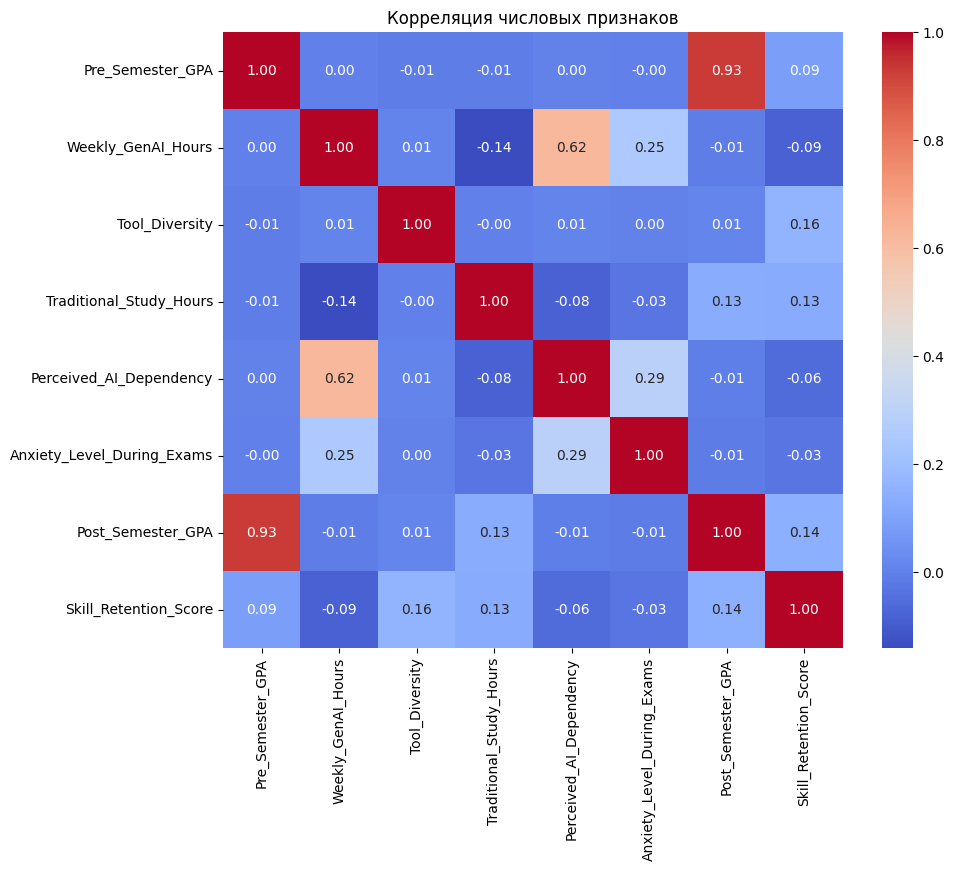

In [238]:
# Корреляция числовых фичей

plt.figure(figsize=(10, 8))
feature_correlation = num_features.corr()
sns.heatmap(feature_correlation, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Корреляция числовых признаков')
plt.show()

Корреляции:
- Очевидная зависимость оценки в начале семестра и в конце (Pre/Post_Semester_GPA)
- Большая корреляция Зависимости студента от ИИ и часов использования ИИ (Weekly_GenAI_Hours и Perceived_AI_Dependency)

<p></p>

- Skill_Retention_Score прямо зависит от оценок в начале семестра и в конце (Pre/Post_Semester_GPA)
- Skill_Retention_Score прямо зависит от количества разных используемых ИИ инструментов (Tool_Diversity)
- Skill_Retention_Score обратная зависимость от кол-ва часов использования ИИ (Weekly_GenAI_Hours) и прямо от традиционных часов на учебу (Traditional_Study_Hours)

<p></p>


- Прямая корреляция часов использования ИИ/Зависимости от ИИ и степени тревожности на экзамене (Weekly_GenAI_Hours/Perceived_AI_Dependency и Anxiety_Level_During_Exams)
- Обратная корреляция часов использования ИИ и традиционных часов на учебу (Weekly_GenAI_Hours и Traditional_Study_Hours)

<p></p>

<b>Можем предположить, что использование ИИ обратно сказывается на успеваемости студента с точки зрения усваивания знаний по предмету, а также повышает тревожность на экзамене. 

In [239]:
print(num_features.columns.to_list())

['Pre_Semester_GPA', 'Weekly_GenAI_Hours', 'Tool_Diversity', 'Traditional_Study_Hours', 'Perceived_AI_Dependency', 'Anxiety_Level_During_Exams', 'Post_Semester_GPA', 'Skill_Retention_Score']


In [240]:
print(cat_features.columns.to_list())

['Major_Category', 'Year_of_Study', 'Primary_Use_Case', 'Prompt_Engineering_Skill', 'Institutional_Policy', 'Burnout_Risk_Level']


C:\Users\User\AppData\Local\Temp\ipykernel_31496\2665855403.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\User\AppData\Local\Temp\ipykernel_31496\2665855403.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\User\AppData\Local\Temp\ipykernel_31496\2665855403.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


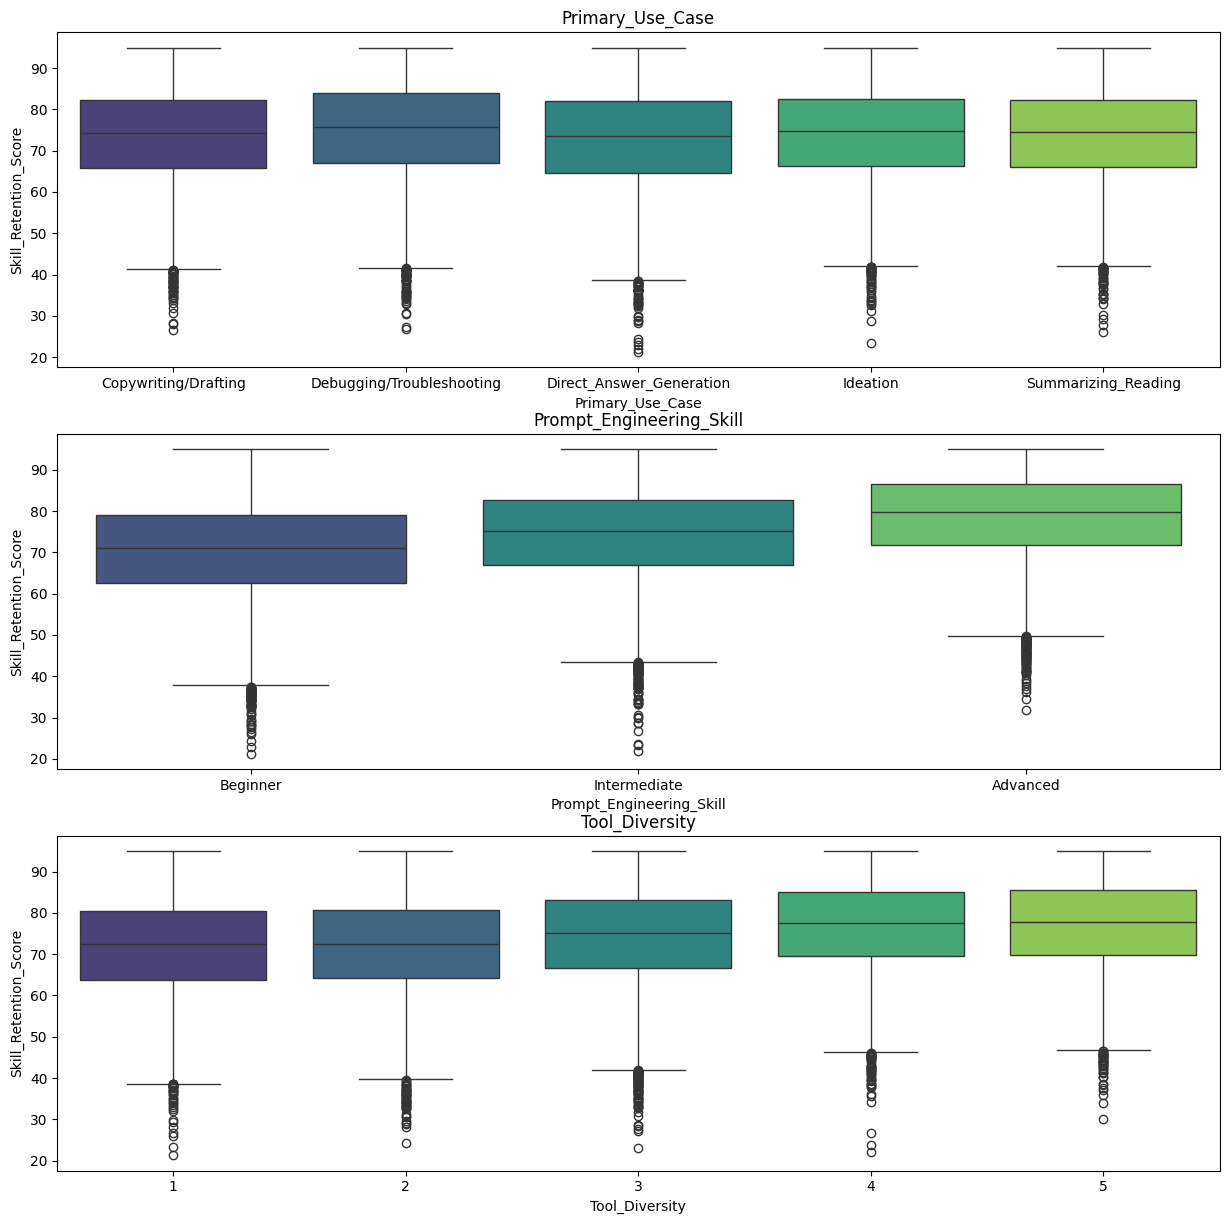

In [241]:
# Ящики с усами по категорияльным признакам и Skill_Retention_Score

plt.figure(figsize=(15, 20))

cols = [
    'Primary_Use_Case',
    'Prompt_Engineering_Skill',
    'Tool_Diversity'
]

for num, col in enumerate(cols):
    plt.subplot(4, 1, num+1)
    sns.boxplot(
            data=df,
            x=col,
            y="Skill_Retention_Score",
            palette="viridis",
        )
    plt.title(col)

plt.show()

Заметим, что худший результат показали студенты, использующие ИИ для получения конечного ответа. Они же показали наибольшее кол-во выбросов с низким усвоением материала.<p>
Но студенты, обладающие лучшими навыками владения ИИ и использующие больше разнообразных инструментов, имеют лучшие результаты.<p>
<b>Предположим, что бездумное использование ИИ ухудшает усвоение материала, а умелое напротив - повышает результативность.

C:\Users\User\AppData\Local\Temp\ipykernel_31496\3250317331.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\User\AppData\Local\Temp\ipykernel_31496\3250317331.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


Text(0.5, 1.0, 'Burnout_Risk_Level - Weekly_GenAI_Hours')

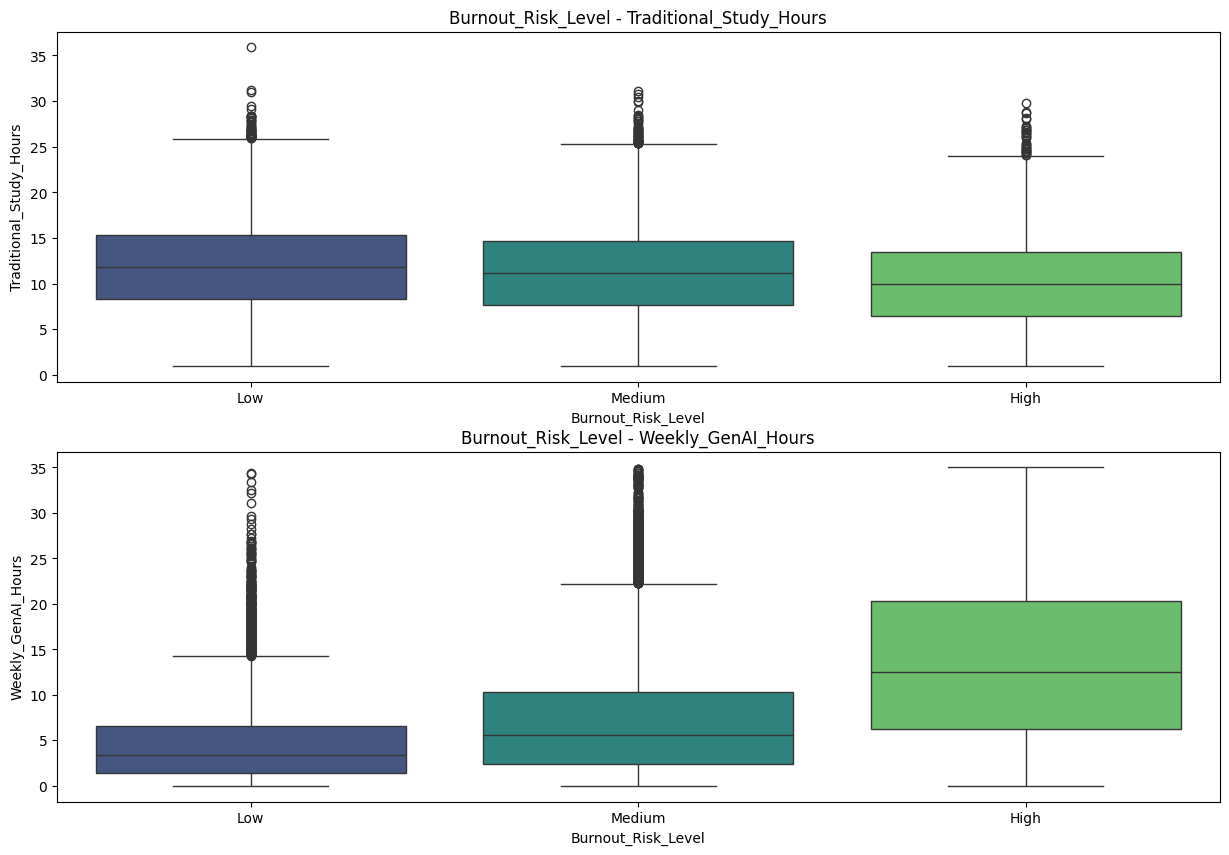

In [242]:
# Ящики с усами - время традиционного обучения и с ИИ

plt.figure(figsize=(15, 10))

plt.subplot(2, 1, 1)
sns.boxplot(
        data=df,
        x='Burnout_Risk_Level',
        y="Traditional_Study_Hours",
        palette="viridis",
    )
plt.title('Burnout_Risk_Level - Traditional_Study_Hours')

plt.subplot(2, 1, 2)
sns.boxplot(
        data=df,
        x='Burnout_Risk_Level',
        y="Weekly_GenAI_Hours",
        palette="viridis",
    )
plt.title('Burnout_Risk_Level - Weekly_GenAI_Hours')

Студенты с 

In [243]:
num_features = df.select_dtypes(include=[np.number])
print(num_features.columns.to_list())

['Pre_Semester_GPA', 'Weekly_GenAI_Hours', 'Tool_Diversity', 'Traditional_Study_Hours', 'Perceived_AI_Dependency', 'Anxiety_Level_During_Exams', 'Post_Semester_GPA', 'Skill_Retention_Score']


C:\Users\User\AppData\Local\Temp\ipykernel_31496\1725000459.py:12: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
C:\Users\User\AppData\Local\Temp\ipykernel_31496\1725000459.py:12: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


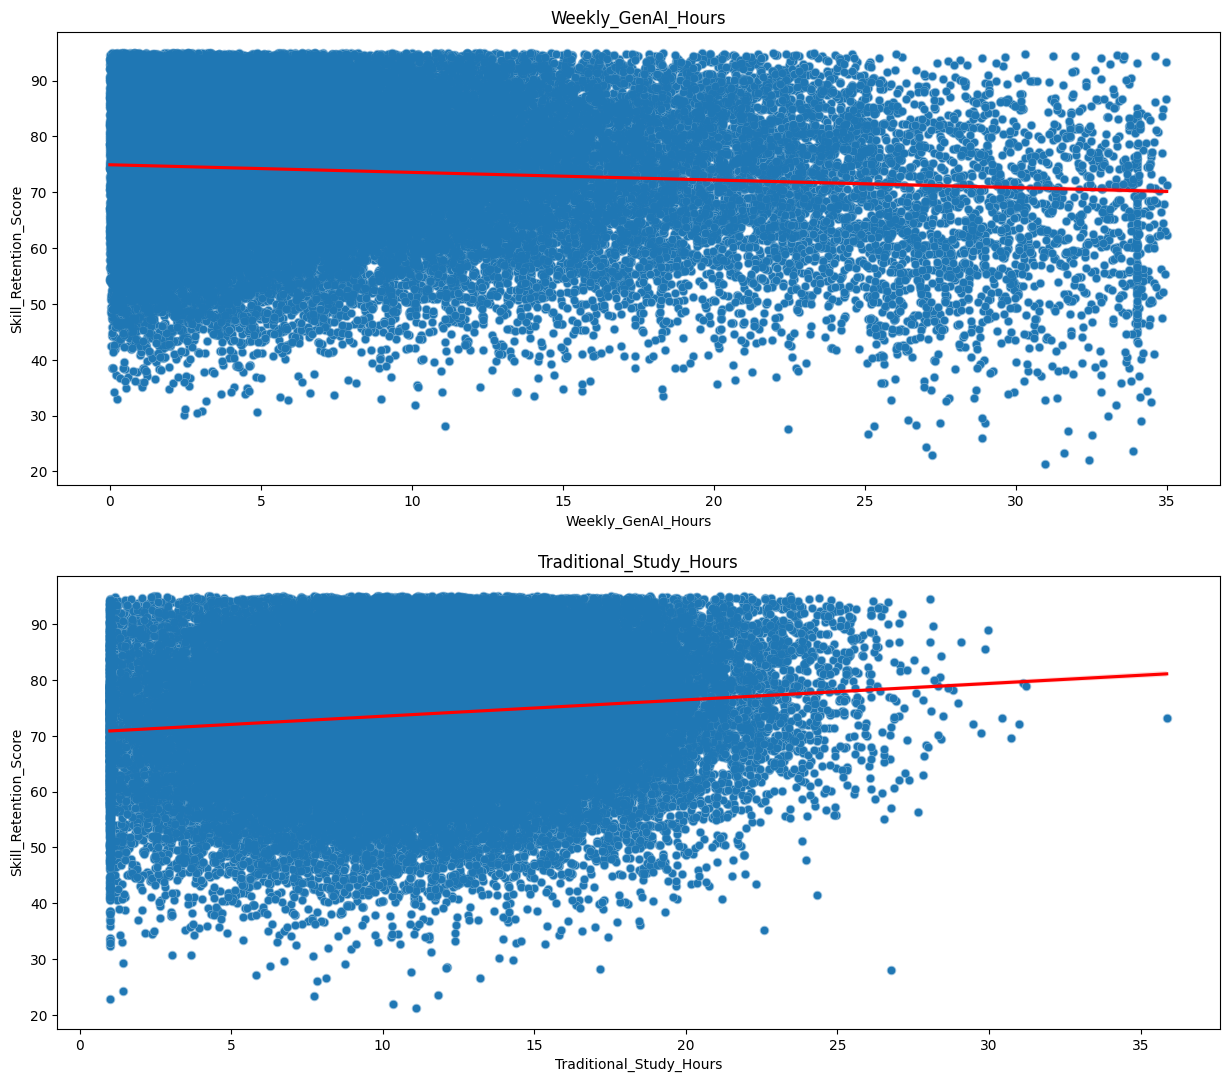

In [249]:
# Зависимость времени традиционного обучения и использования ИИ на усвоение материала

plt.figure(figsize=(15, 20))

cols = [
    'Weekly_GenAI_Hours',
    'Traditional_Study_Hours',
]

for num, col in enumerate(cols):
    plt.subplot(3, 1, num+1)
    sns.scatterplot(
            data=df,
            x=col,
            y="Skill_Retention_Score",
            palette="viridis",
        )
    sns.regplot(
        data=df, 
        x=col, 
        y="Skill_Retention_Score",
        scatter_kws={'alpha':0.3},
        line_kws={'color': 'red'}
    )
    plt.title(col)

plt.show()

При повышении традиционных часов на обучение повышается и минимальный уровень освоения материала.<p>
При излишнем использовании ИИ (примерно >25ч в неделю) усваиваемость начинает падать.<p>
<b>Предположим, что черезмерное использование ИИ может вредить успеваемости

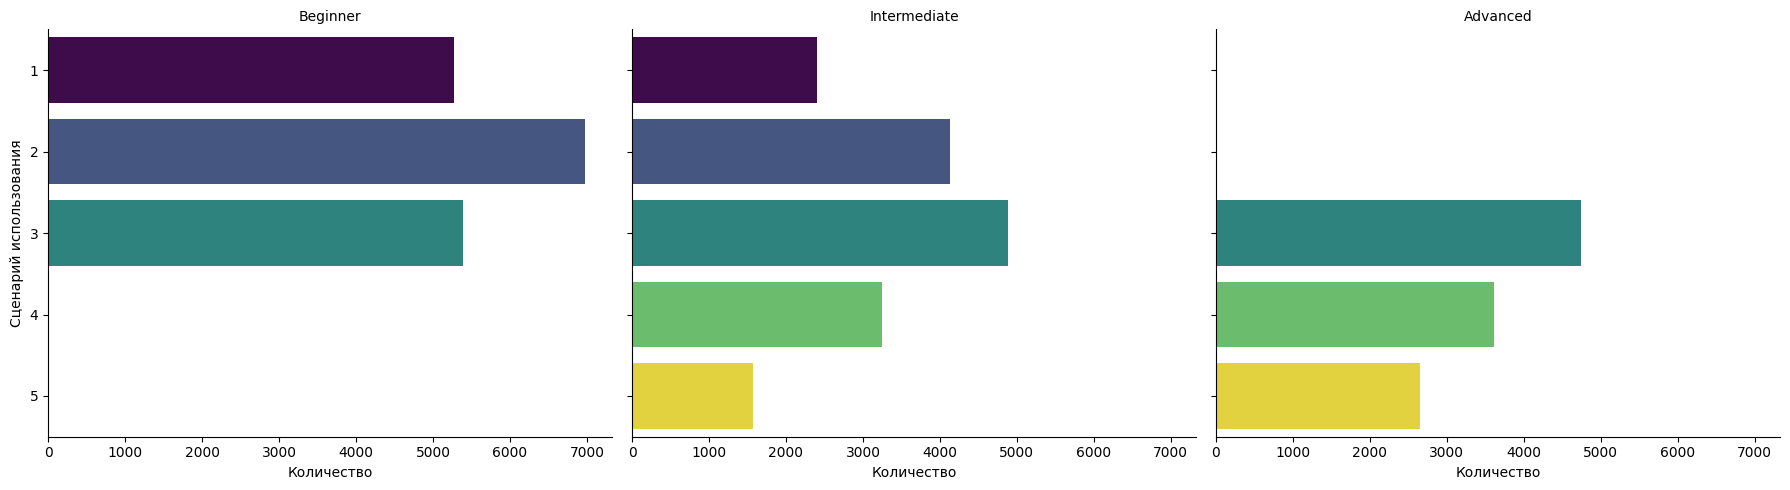

In [245]:
g = sns.catplot(
    data=df,
    y="Tool_Diversity",       # Названия кейсов по вертикали (чтобы текст читался)
    hue="Tool_Diversity",     # Красим каждый кейс в свой цвет (опционально)
    kind="count",               # Считаем количество строк
    col="Prompt_Engineering_Skill", # Для каждого навыка — своя колонка
    col_wrap=3,                 # Если навыков много, переносим на новую строку (например, по 3 в ряд)
    height=5,                   # Высота каждого подграфика
    aspect=1.2,                 # Пропорции (ширина = height * aspect)
    palette="viridis",          # Приятная цветовая палитра
    legend=False                # Отключаем общую легенду, так как оси Y подписаны
)

# Настройка заголовков подграфиков
g.set_titles("{col_name}")
g.set_axis_labels("Количество", "Сценарий использования")

plt.tight_layout()
plt.show()

In [253]:
# Введем новые информативные признаки

df['GPA_Delta'] = df['Post_Semester_GPA'] - df['Pre_Semester_GPA']     # Разница между началом и концом года
df['Academic_Perfomance_Drop'] = df['GPA_Delta'] < 0                    # Было ли ухудшение успеваемости
df['High_Risk_Student'] = (
    (df['Burnout_Risk_Level'] == 'High') & \
    (df['Anxiety_Level_During_Exams'] > 7)
)                                                                       # Находится ли стундент в зоне риска

C:\Users\User\AppData\Local\Temp\ipykernel_31496\3070023848.py:10: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
C:\Users\User\AppData\Local\Temp\ipykernel_31496\3070023848.py:10: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


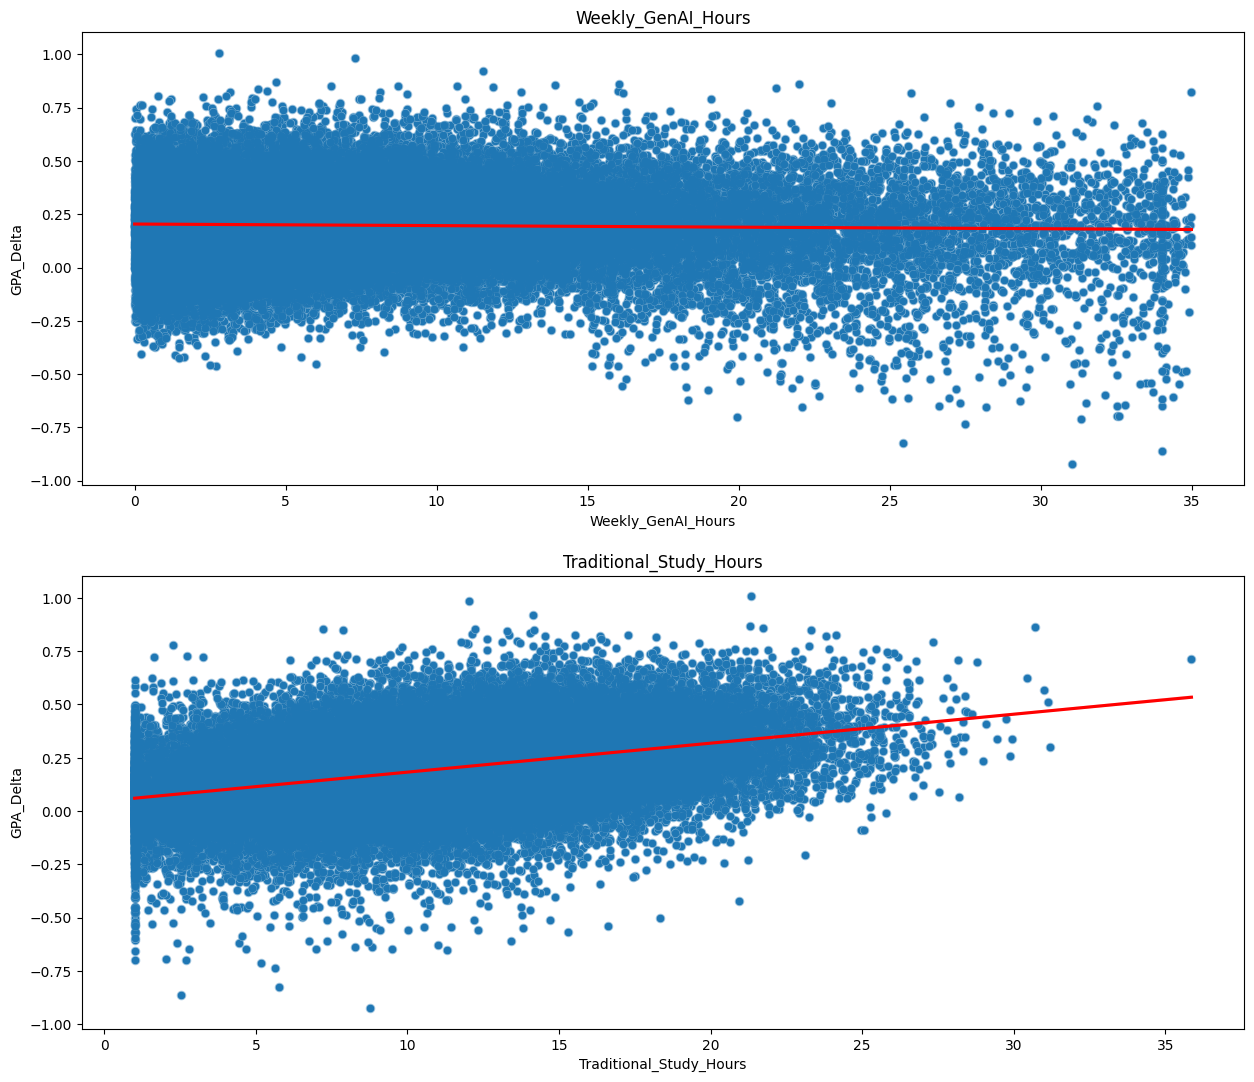

In [247]:
plt.figure(figsize=(15, 20))

cols = [
    'Weekly_GenAI_Hours',
    'Traditional_Study_Hours',
]

for num, col in enumerate(cols):
    plt.subplot(3, 1, num+1)
    sns.scatterplot(
            data=df,
            x=col,
            y="GPA_Delta",
            palette="viridis",
        )
    sns.regplot(
        data=df, 
        x=col, 
        y="GPA_Delta",
        scatter_kws={'alpha':0.3},
        line_kws={'color': 'red'}
    )
    plt.title(col)

plt.show()

Студенты, больше занимающиеся традиционно, улучшали свои показатели к концу года. <p>
Студенты, черезмерно использовавшие ИИ, чаще ухудшали свои показатели к концу года

C:\Users\User\AppData\Local\Temp\ipykernel_31496\3863168735.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


Text(0.5, 1.0, 'Burnout_Risk_Level - Traditional_Study_Hours')

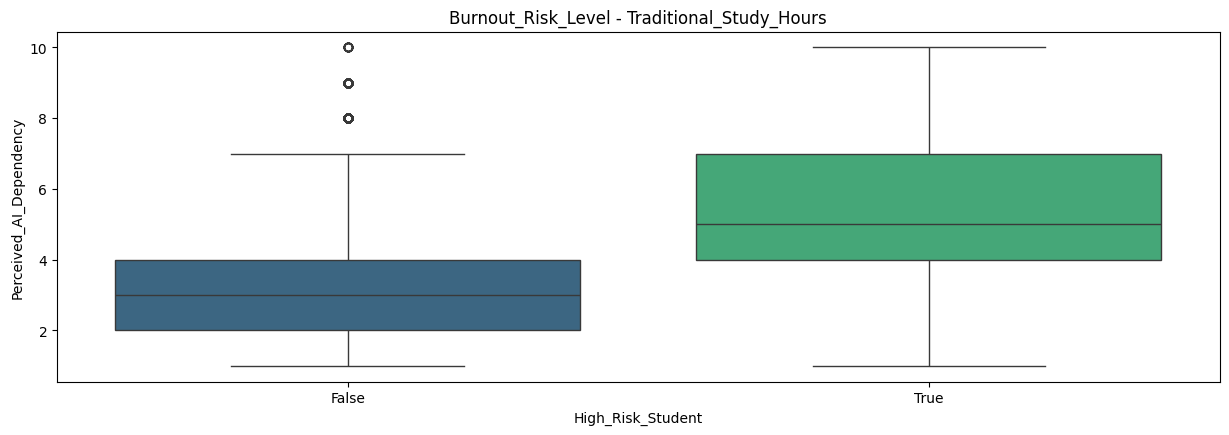

In [254]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 1, 1)
sns.boxplot(
        data=df,
        x='High_Risk_Student',
        y="Perceived_AI_Dependency",
        palette="viridis",
    )
plt.title('Burnout_Risk_Level - Traditional_Study_Hours')

C:\Users\User\AppData\Local\Temp\ipykernel_31496\2617267359.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


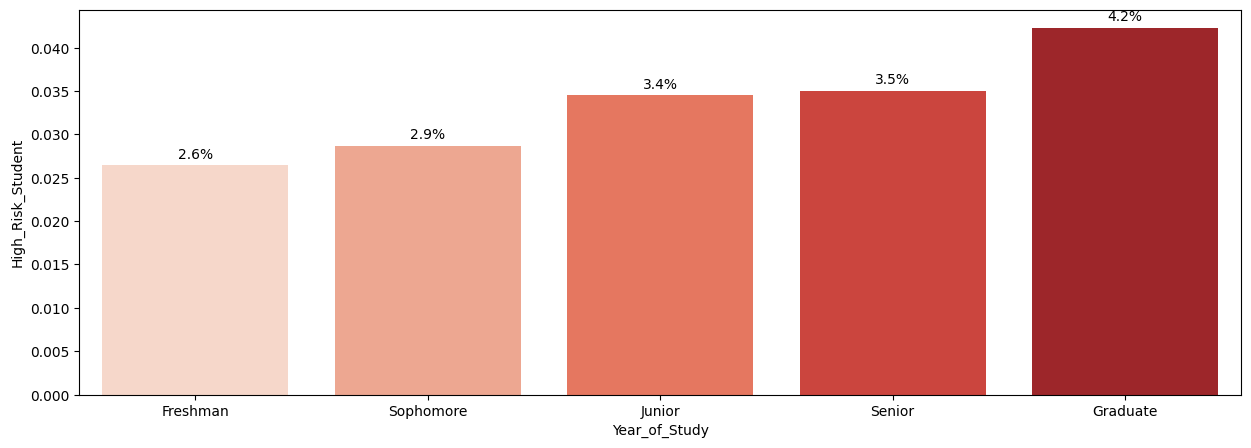

C:\Users\User\AppData\Local\Temp\ipykernel_31496\2617267359.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


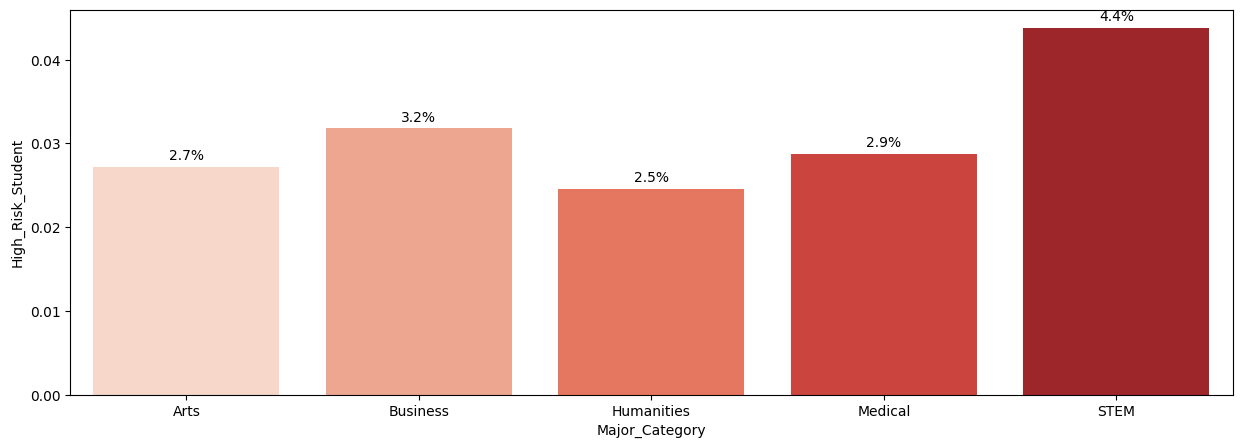

C:\Users\User\AppData\Local\Temp\ipykernel_31496\2617267359.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


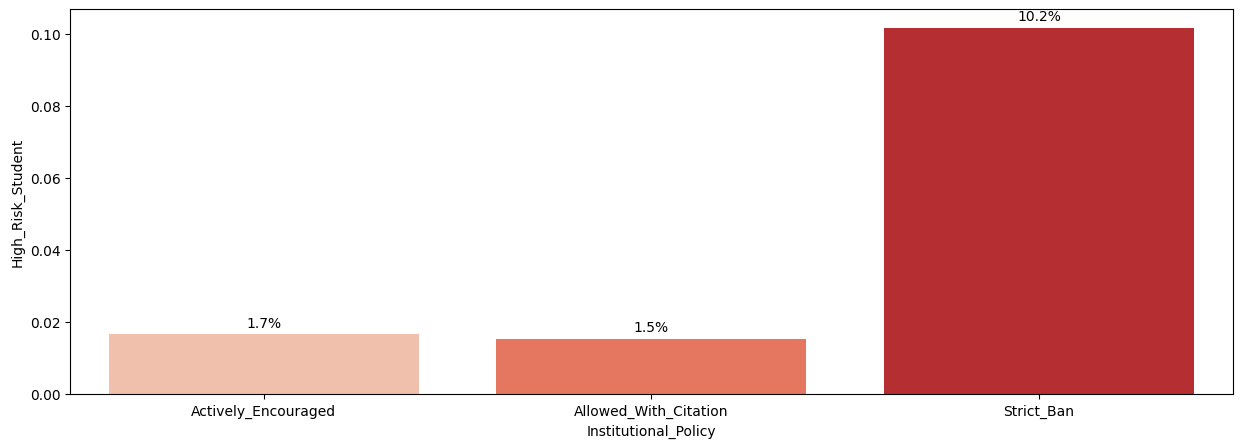

C:\Users\User\AppData\Local\Temp\ipykernel_31496\2617267359.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


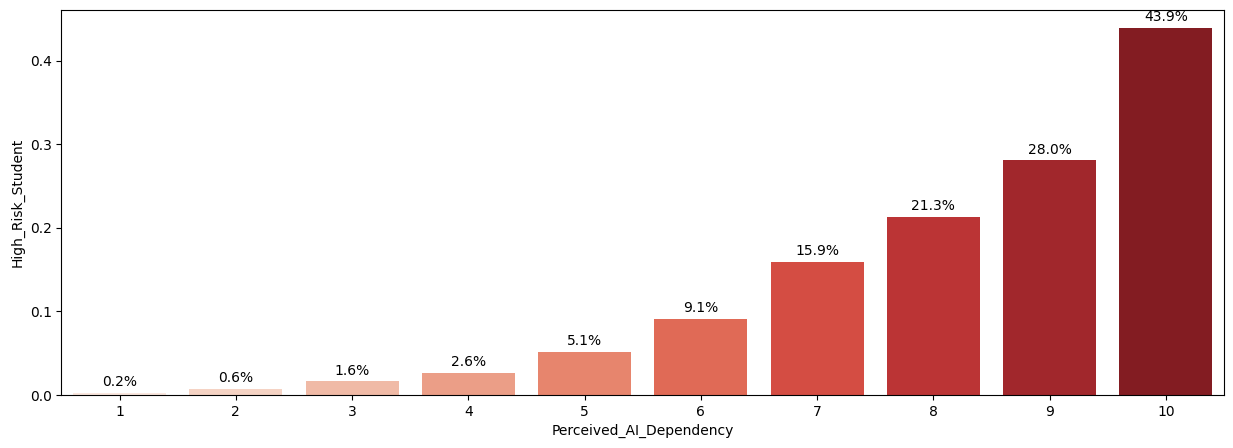

C:\Users\User\AppData\Local\Temp\ipykernel_31496\2617267359.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


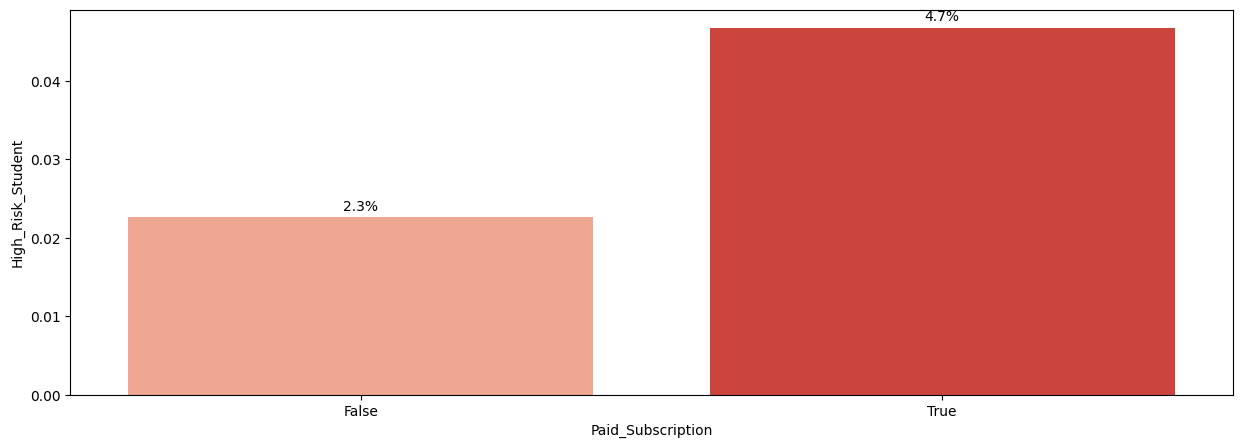

C:\Users\User\AppData\Local\Temp\ipykernel_31496\2617267359.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


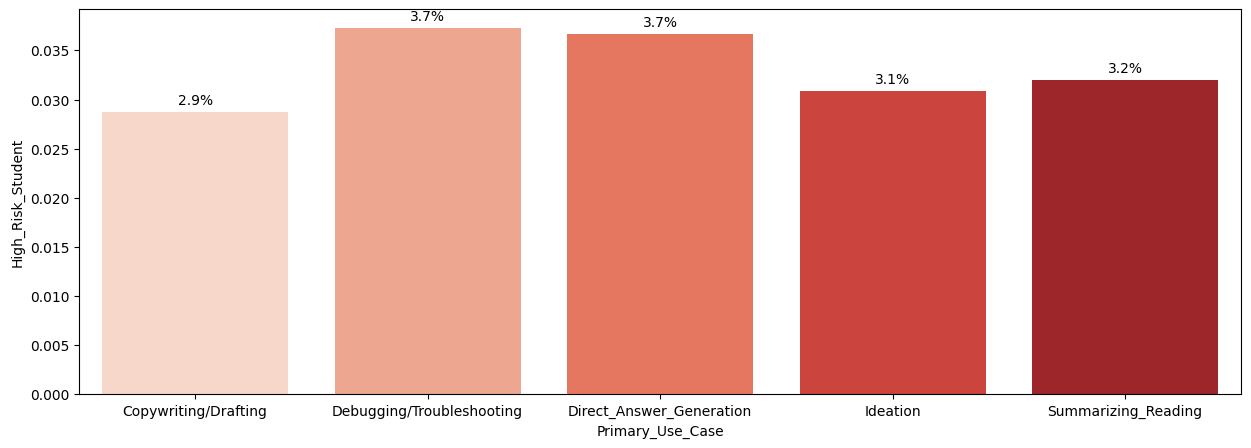

In [268]:
cols = [
    'Year_of_Study',
    'Major_Category',
    'Institutional_Policy',
    'Perceived_AI_Dependency',
    'Paid_Subscription',
    'Primary_Use_Case'
]

for col in cols:
    plt.figure(figsize=(15, 5))
    ax = sns.barplot(
        data=df, 
        x=col, 
        y="High_Risk_Student",
        palette="Reds",
        errorbar=None
    )

    for container in ax.containers:
        ax.bar_label(container, fmt=lambda x: f'{x*100:.1f}%', padding=3)
    plt.show()

Проанализировав студентов в зоне риска (Высокий уровень выгорания и высокий уровень стресса на экзамене) можно сделать выводы:
- Чем старше курс, тем больше студентов в зоне риска
- Строгий запрет ИИ способствует сильному росту студентов в зоне риска (использование ИИ против правил ВУЗа?)
- Степень зависимости от ИИ коррелирует с процентом студентов в зоне риска